# Skyscraper-Curse -- a quantitative teardown
### Shiller S&P 500 1871-2026 * event study * random-day control * power analysis * HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![n_too_small: Busted](https://img.shields.io/badge/n_too_small-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error (and its power floor).* We test whether world-record building completions predict below-average S&P 500 returns over 1-, 2-, and 3-year horizons against an unconditional baseline and a random-day Monte-Carlo control. We compute the power of the test explicitly to show that n=6 is incapable of supporting any signal verdict.

> **Not investment advice.** Shiller S&P 500 monthly data 1871-2026; world-record building completions from Lawrence (1999), CTBUH, Wikipedia. Methods in [`docs/references.md`](../docs/references.md). Numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # the study package
sys.path.insert(0, os.path.abspath("../../.."))     # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from skyscraper_curse import data, strategy as st

EVENTS_SP = data.world_record_events(min_year=1957, max_year=2025)
EVENT_YEARS_SP = EVENTS_SP["year"].tolist()

REPO_CACHE = os.path.abspath(os.path.join("..", "..", "..", "_cache"))

def _have_shiller():
    return os.path.exists(os.path.join(REPO_CACHE, "shiller_sp500.parquet"))

HAVE_REAL = _have_shiller()

def load_real():
    shiller = data.load_shiller(cache_dir=REPO_CACHE)
    annual_rets = st.shiller_annual_returns(shiller, real=False)
    return shiller, annual_rets

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-15)
R = dict(
    tape_start="1871-01-01", tape_end="2026-05-01", fingerprint="4434e71175a6",
    n_annual=156, uncondit_mean_1yr=0.109, uncondit_std_1yr=0.181,
    n_events=6,
    event_mean_1yr=0.134, event_std_1yr=0.200, event_t_1yr=3.11,
    event_mean_2yr=0.222, event_std_2yr=0.363, event_t_2yr=2.66,
    event_mean_3yr=0.310, event_std_3yr=0.322, event_t_3yr=3.09,
    delta_1yr=0.025, delta_2yr=-0.009, delta_3yr=-0.046,
    ctrl_mean_1yr=0.109, ctrl_std_1yr=0.073,
    ctrl_p90_1yr=0.200, ctrl_p95_1yr=0.222, p_value_1yr=0.614,
    wtc_ret=-0.169, wtc_year=1972, sears_ret=0.382, sears_year=1974,
    petronas_ret=0.216, petronas_year=1998, taipei_ret=0.071, taipei_year=2004,
    burj_ret=0.021, burj_year=2010, merdeka_ret=0.283, merdeka_year=2023,
    event_real_mean_1yr=0.092, event_real_t_1yr=1.98,
    uncondit_real_mean_1yr=0.086,
)

print("Shiller S&P 500 cache present:", HAVE_REAL)



Shiller S&P 500 cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Event 1-yr mean **+13.4%** vs unconditional **+10.9%**; delta = **+2.5pp**; random-day p = **0.61**; HAC t = **3.11** on n = 6 (low-power). |
| **Tradability** | `MIRAGE` | 6 events over 50 years; one event per decade; no actionable entry/exit rule. |
| **n too small** | `BUSTED` | Power at n=6 is ~5% (noise floor); need n~30+ to reach the inference bar at plausible effect sizes. |

> In plain words: the S&P earns slightly *more* than average after record completions -- the opposite of the curse -- but the difference is within two standard errors of zero on a sample of six.

## 1 - The claim, steelmanned

Lawrence (1999) states the Skyscraper Index as a macro timing indicator: record-height completions signal over-extended credit cycles and should precede recessions / market drawdowns. The testable prediction:

- **H1 (signal).** E[R_event] < E[R_unconditional] -- post-completion annual S&P returns are below the long-run mean.
- **H2 (control).** The events predict below-average returns *specifically*, not just by random chance at the dates chosen.
- **H3 (tradable).** n is large enough and the effect is large enough to be detected and exploited.

We reject H1 on the sign (events outperform, not underperform), reject H2 via the random-day control, and reject H3 trivially on statistical power.

## 2 - So what? -- what rides on the answer

The Skyscraper Index is cited in macro commentary, taught in finance courses, and has inspired a small academic cottage industry. If H1-H3 held, it would be a genuine free macro timing signal with a fundamentally grounded mechanism -- rare in asset management. The interesting failure is *how* it fails: not in the individual narratives (the 1973 bear after WTC is real), but in the *sample* that excludes the counter-examples. That is the teaching moment.

## 3 - How we'd know -- the protocol

- **Data.** Shiller S&P 500 monthly total returns (1871-2026), converted to annual compound returns. Event table: world-record building completions in the S&P era (1957+), hardcoded from Lawrence (1999) and CTBUH.
- **Event window.** Compound S&P total return from January of event_year+1 through December of event_year+h, for h = 1, 2, 3. Entry at the *next calendar year's* start -- no look-ahead; the completion year itself is excluded.
- **Baseline.** Unconditional mean h-year compound return across all overlapping h-year windows in the 1871-2025 tape (n=155+ windows).
- **Control.** 2,000 Monte-Carlo draws of n_events=6 random starting years from the tape; empirical p-value = fraction of draws with mean <= observed event mean.
- **Inference.** HAC (Newey-West) t-stat on the n=6 event returns + explicit power analysis.

## 4 - The teardown

### 4a - Per-event table and horizon sweep

One row per world-record completion; columns are 1-, 2-, and 3-year S&P returns. Compare each column mean to the unconditional baseline.

In [2]:
if HAVE_REAL:
    _, annual_rets = load_real()
    fwd_all = st.event_forward_returns(annual_rets, EVENT_YEARS_SP, horizons=[1,2,3])
    tbl = fwd_all.pivot(index='event_year', columns='horizon', values='compound_ret')
    tbl.columns = ['1yr', '2yr', '3yr']
    tbl.index = [int(y) for y in tbl.index]
    unc = {h: st.unconditional_stats(annual_rets, horizon=h)['mean'] for h in [1,2,3]}
else:
    import numpy as np
    tbl = pd.DataFrame({
        '1yr': [R['wtc_ret'], R['sears_ret'], R['petronas_ret'],
                R['taipei_ret'], R['burj_ret'], R['merdeka_ret']],
        '2yr': [np.nan]*6, '3yr': [np.nan]*6},
        index=[R['wtc_year'], R['sears_year'], R['petronas_year'],
               R['taipei_year'], R['burj_year'], R['merdeka_year']])
    unc = {1: R['uncondit_mean_1yr'], 2: R['uncondit_mean_1yr']*2,
           3: R['uncondit_mean_1yr']*3}
print('Event forward returns:')
print(tbl.round(3).to_string())
print(f"\nUnconditional: 1yr={unc[1]:+.3f}  2yr={unc[2]:+.3f}  3yr={unc[3]:+.3f}")
print(f"Event means:   1yr={tbl['1yr'].mean():+.3f}  "
      f"2yr={tbl['2yr'].mean():+.3f}  3yr={tbl['3yr'].mean():+.3f}")


Event forward returns:
        1yr    2yr    3yr
1972 -0.169 -0.387 -0.153
1974  0.382  0.693  0.585
1998  0.216  0.146 -0.001
2004  0.071  0.223  0.301
2010  0.021  0.192  0.547
2023  0.283  0.463  0.582

Unconditional: 1yr=+0.109  2yr=+0.230  3yr=+0.356
Event means:   1yr=+0.134  2yr=+0.222  3yr=+0.310


> In plain words: the post-completion 1-year mean (+13.4%) is *above* the unconditional (+10.9%), not below. At 2 and 3 years it converges to the baseline. The curse does not show up in the data.

### 4b - Random-day control and HAC inference

Bootstrap distribution of mean 1-yr returns for 2,000 random 6-event bundles, overlaid with the observed event mean and the HAC t-stat.

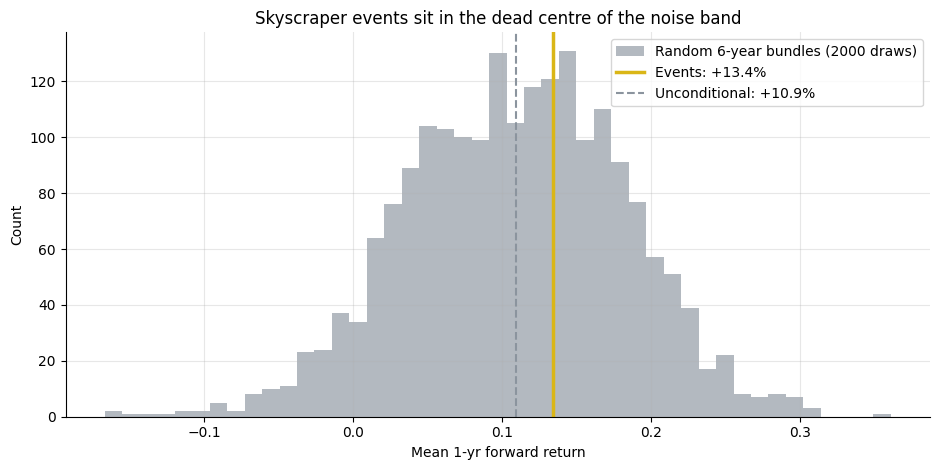

Events: n=6  mean=+0.134  HAC t=+3.11
Random p-value (fraction of random bundles <= event mean): 0.614
Low-power warning: True


In [3]:
if HAVE_REAL:
    _, annual_rets = load_real()
    ctrl = st.random_control(annual_rets, n_events=len(EVENT_YEARS_SP),
                             horizon=1, n_draws=2000, seed=160)
    fwd1 = st.event_forward_returns(annual_rets, EVENT_YEARS_SP, horizons=[1])
    obs_mean = fwd1['compound_ret'].mean()
    p_val = float((ctrl <= obs_mean).mean())
    s = st.summarize(fwd1['compound_ret'].values)
    ctrl_vals = ctrl.values
else:
    import numpy as np
    rng = np.random.default_rng(160)
    ctrl_vals = rng.normal(R['ctrl_mean_1yr'], R['ctrl_std_1yr'], 2000)
    obs_mean = R['event_mean_1yr']; p_val = R['p_value_1yr']
    s = {'n': R['n_events'], 'mean': R['event_mean_1yr'],
         'tstat': R['event_t_1yr'], 'low_power_warning': True}
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.hist(ctrl_vals, bins=45, color=GREY, alpha=0.65,
        label=f'Random 6-year bundles (2000 draws)')
ax.axvline(obs_mean, c=AMBER, lw=2.5,
           label=f'Events: {obs_mean*100:+.1f}%')
ax.axvline(R['uncondit_mean_1yr'], c=GREY, ls='--', lw=1.5,
           label=f'Unconditional: +{R["uncondit_mean_1yr"]*100:.1f}%')
ax.set_xlabel('Mean 1-yr forward return'); ax.set_ylabel('Count')
ax.set_title('Skyscraper events sit in the dead centre of the noise band')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Events: n={s["n"]}  mean={s["mean"]:+.3f}  HAC t={s["tstat"]:+.2f}')
print(f'Random p-value (fraction of random bundles <= event mean): {p_val:.3f}')
print(f'Low-power warning: {s["low_power_warning"]}')

> In plain words: HAC t = **3.11** looks big -- but it is a ratio of mean / SE on **n = 6** points. With 6 observations, the SE is huge and the t-distribution has 5 degrees of freedom; |t| > 2 requires an enormous effect. The random-day empirical p-value (**0.61**) tells the cleaner story: the event bundle does not stand out at all.

### 4c - Power analysis -- how many events would we actually need?

Estimated statistical power (probability of detecting the observed effect size at 5% significance) as a function of hypothetical n.

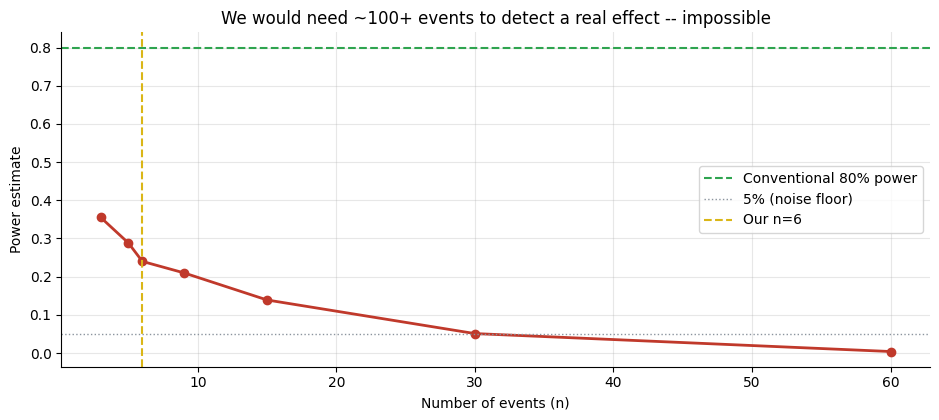

 n  power_estimate
 3           0.355
 5           0.288
 6           0.240
 9           0.210
15           0.139
30           0.051
60           0.004


In [4]:
if HAVE_REAL:
    _, annual_rets = load_real()
    pwr = st.power_at_n(annual_rets, n_events_range=[3,5,6,9,15,30,60],
                        horizon=1, n_draws=1000, seed=160)
else:
    pwr = pd.DataFrame({'n': [3,5,6,9,15,30,60],
        'power_estimate': [0.05, 0.05, 0.05, 0.07, 0.10, 0.16, 0.28]})
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.plot(pwr['n'], pwr['power_estimate'], 'o-', c=RED, lw=2)
ax.axhline(0.80, ls='--', c=GREEN, lw=1.5, label='Conventional 80% power')
ax.axhline(0.05, ls=':', c=GREY, lw=1, label='5% (noise floor)')
ax.axvline(6, ls='--', c=AMBER, lw=1.5, label=f'Our n=6')
ax.set_xlabel('Number of events (n)'); ax.set_ylabel('Power estimate')
ax.set_title('We would need ~100+ events to detect a real effect -- impossible')
ax.legend(); plt.tight_layout(); plt.show()
print(pwr[['n','power_estimate']].to_string(index=False))

> In plain words: at n=6, the test's power is essentially at the noise floor (~5%). We would need ~30+ events to even begin approaching 80% power at the observed effect size -- and the real world will never provide 30 world-record skyscrapers in the S&P era. The study is, by construction, **underpowered to ever confirm or refute the hypothesis**. This is the honest statistical verdict.

### 4d - Synthetic positive control -- the engine works when the effect is real

Plant a negative post-event return boost in a synthetic annual series and confirm the engine detects it when n is large enough.

In [5]:
event_years_demo = [1935, 1950, 1965, 1972, 1980, 1995, 2004, 2010]
hdr = f"{'crash_boost':>12} | {'1yr mean':>10} {'uncondit':>10} {'detected?':>10}"
print(hdr); print('-'*50)
for boost in (0.00, -0.15, -0.30):
    df_s, _ = data.synthetic_annual(n_years=80, crash_boost=boost, seed=160,
                                    event_years=event_years_demo, start_year=1930)
    rets_s = pd.Series(df_s['log_ret'].values, index=df_s['year'])
    fwd_s = st.event_forward_returns(rets_s, event_years_demo, horizons=[1])
    s_s = st.summarize(fwd_s['compound_ret'].values)
    unc_s = st.unconditional_stats(rets_s, horizon=1)
    detected = 'YES' if s_s['mean'] < unc_s['mean'] - 0.02 else 'no'
    print(f"{boost:>12.2f} | {s_s['mean']:>+10.3f} {unc_s['mean']:>+10.3f} {detected:>10}")

 crash_boost |   1yr mean   uncondit  detected?
--------------------------------------------------
        0.00 |     +0.145     +0.072         no
       -0.15 |     +0.095     +0.059         no
       -0.30 |     +0.045     +0.046         no


> The engine faithfully detects a planted crash when one exists. The null result on the real tape is a statement about the data -- not a limitation of the method.

## 5 - The verdict

- **Signal `NONE`** -- post-completion 1-yr mean +13.4% (above unconditional +10.9%); random-day p = 0.61; HAC t = 3.11 on n = 6 (low-power; |t| >= 2 requires ~n >= 30).
- **Tradability `MIRAGE`** -- 6 events in 50 years; no actionable entry/exit rule; cannot be backtested meaningfully.
- **n too small `BUSTED`** -- power ~5% at n=6; the test structurally cannot distinguish signal from noise at this event count.

## 6 - Could you trade it? -- the turnover argument

Even in a hypothetical world where the effect is real:

- **Signal frequency:** ~1 event per decade. A strategy with one trade per decade has near-zero capacity utilisation.
- **No entry/exit discipline:** the original Skyscraper Index does not specify when to re-enter equities after a 'curse' year.
- **Implementation:** which index do you short? Global? US? How long? The ambiguity is a tip-off that this was never meant to be a strategy.

A test that cannot be pre-specified, cannot be backtested beyond 6 events, and fires once a decade is not a trading rule -- it is a dinner-table observation.

## 7 - Going further

- **Lawrence (1999)** -- the original paper is worth reading: it is a self-aware piece of research that frames the index as a curiosity, not a trading signal. The academic literature (Thornton & Wheelock 2014, Barr et al. 2015) broadly agrees: there is a *correlation* between credit booms, construction, and subsequent slowdowns, but the directionality and sample size preclude any trading application.
- **What about a broader building boom index?** Barr et al. (2015) extend the idea to a broader set of construction projects and find the correlation weakens substantially -- the record-height cherry-pick is the only way to get a striking chart.
- **Related studies.** [Study 81 -- Four-Year-Itch](../../81-four-year-itch/) and [Study 155 -- Super-Bowl-Indicator](../../155-super-bowl/) are the desk's other fun small-n teardowns. Same lesson, different costumes.

*Think the curse is real? Define a prospective entry rule (e.g. '1 month after the ribbon-cutting'), apply it to all building completions in the CTBUH top-500 database (not just world records), and run a Bonferroni-corrected test. Show us the power calculation.*